In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\Juan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [6]:
from IPython.display import Image
from keras.api.datasets import fashion_mnist

In [7]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
x_train.shape

(60000, 28, 28)

In [9]:
x_test.shape

(10000, 28, 28)

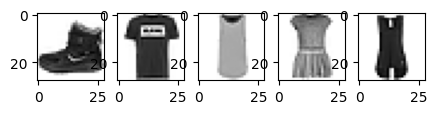

In [10]:
plt.figure(figsize = (5,5))

for i, image in enumerate(x_train[0:5]):
    plt.subplot(1,5, i+1)
    plt.imshow(image, cmap = plt.cm.binary)

In [11]:
x_train = x_train/255
x_test = x_test/255

In [12]:
x_train = x_train.reshape((x_train.shape[0], 28, 28)).astype("float32")
x_test = x_test.reshape((x_test.shape[0], 28, 28)).astype("float32")

In [13]:
from keras.api.models import Sequential
from keras.api.layers import Flatten, Dense

In [14]:
model = Sequential()

In [15]:
model.add(Flatten(input_shape = [28,28]))
model.add(Dense(300, activation = "relu"))
model.add(Dense(100, activation = "relu"))

C:\Users\Juan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.add(Dense(10, activation = "softmax"))
#A este punto, ya se ha creado toda la red neuronal
#Tiene una capa Flatten, dos capas ocultas densas y una de salida que se activa con SoftMax

In [17]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["sparse_categorical_accuracy"])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.fit(x_train, y_train, epochs = 5, verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.5922 - sparse_categorical_accuracy: 0.7908
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.3588 - sparse_categorical_accuracy: 0.8683
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.3333 - sparse_categorical_accuracy: 0.8771
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.3021 - sparse_categorical_accuracy: 0.8883
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.2880 - sparse_categorical_accuracy: 0.8931


In [20]:
loss, accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3607 - sparse_categorical_accuracy: 0.8702


In [21]:
index = np.random.randint(0, 1000, 1)
index

array([500], dtype=int32)

In [22]:
test = x_train[index]

y_pred = model.predict(test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


In [23]:
y_pred #Esta vaina da probabilidades

array([[6.1787607e-04, 1.9406580e-05, 3.1301889e-03, 9.4179451e-01,
        4.6789292e-02, 1.1739402e-06, 7.4709971e-03, 4.9488062e-08,
        1.7642285e-04, 3.9113651e-08]], dtype=float32)

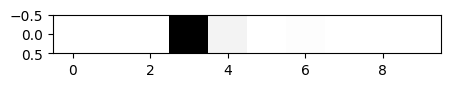

In [24]:
plt.figure(figsize = (5,5))
plt.imshow(y_pred, cmap = plt.cm.binary)

In [25]:
y_train[index] #Waos, 100% de precisión

array([3], dtype=uint8)

In [26]:
from keras.api.models import  Sequential
from keras.api.layers import Dense, Flatten, Dropout
from keras.api.utils import to_categorical

In [27]:
from keras.api.datasets import mnist

In [28]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() #load_data es solo para los datasets de tensorflow

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [29]:
x_test.shape

(10000, 28, 28)

In [30]:
x_train = x_train.reshape(x_train.shape[0], 28, 28).astype("float32")/255 #Normalizando x_train
x_test = x_test.reshape(x_test.shape[0], 28, 28).astype("float32")/255 #Normalizando x_test

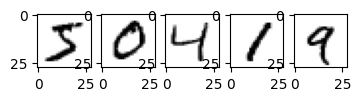

In [31]:
plt.figure(figsize = (4,3))
for i, imagen in enumerate(x_train[0:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(imagen, cmap = plt.cm.binary)

In [32]:
model = Sequential()

In [33]:
model.add(Flatten(input_shape = [28,28]))
model.add(Dense(300, activation = "relu"))
model.add(Dropout(0.2))
model.add(Dense(80, activation = "relu"))
model.add(Dense(10, activation = "softmax"))

In [34]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["sparse_categorical_accuracy"])

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 80)             │        24,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,390 (1017.15 KB)

 Trainable params: 260,390 (1017.15 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.fit(x_train, y_train, epochs = 5, verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.4030 - sparse_categorical_accuracy: 0.8764
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1084 - sparse_categorical_accuracy: 0.9664
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0825 - sparse_categorical_accuracy: 0.9744
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0637 - sparse_categorical_accuracy: 0.9795
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0511 - sparse_categorical_accuracy: 0.9832


In [37]:
loss, accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0836 - sparse_categorical_accuracy: 0.9766


In [38]:
y_pred = model.predict(x_test[[3]])
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


array([[9.9998868e-01, 6.7911593e-10, 4.7688450e-06, 2.4433198e-09,
        6.2875856e-08, 5.3221139e-09, 2.7824760e-06, 1.3502026e-06,
        1.6205378e-07, 2.2578629e-06]], dtype=float32)

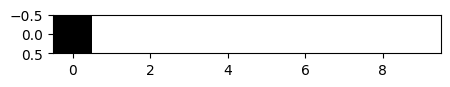

In [39]:
plt.figure(figsize = (5,5))
plt.imshow(y_pred, cmap = plt.cm.binary)

In [40]:
np.argmax(y_pred)

np.int64(0)

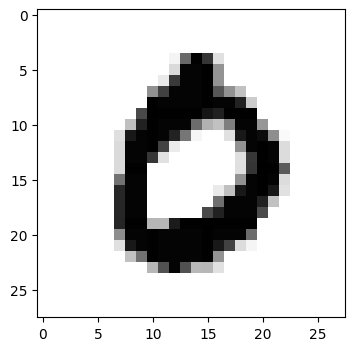

In [41]:
plt.figure(figsize = (4,4)) 
plt.imshow(x_test[3], cmap = plt.cm.binary)